# Epidemics V2.12 - final reproducible analysis

Offline, reproducible workflow for the final *Epidemics* submission. It reconstructs all national COVID-19 waves, reruns the identifiability stress tests, validates the historical national burdens, and regenerates the V2.10 synchronized 1918 infection-equivalent/mortality figure.


In [1]:
from pathlib import Path
import hashlib, json, os, platform, shutil, subprocess, sys
import pandas as pd
from IPython.display import display, Image

HERE = Path.cwd().resolve()
ROOT = HERE.parent if (HERE / 'reconstruct_all_national_waves.py').exists() else HERE
REPRO = ROOT / 'reproducibility'
TABLES = ROOT / 'tables'
FIGURES = ROOT / 'figures'
print('Python:', sys.version)
print('Platform:', platform.platform())
print('Project root:', ROOT)

Python: 3.13.5 (main, Jul 15 2026, 20:25:40) [GCC 14.2.0]
Platform: Linux-6.18.35-x86_64-with-glibc2.41
Project root: /mnt/data/v210final/EPIDEMICS_V210_FULL


## 1. Verify the pinned raw inputs

In [2]:
EXPECTED = {
    'world_mortality.csv': '4bf283d1491425d3d2d2f55b1c211e12d54bb5bbb7c5986fa11814614bd2fa6c',
    'jhu_cases.csv': 'e6234a59eec4359d2577358b5220e1a7e3da74c162913cdb7d882db1413f98c2',
    'jhu_deaths.csv': '4e87757a3e059c45650a1e1856614f8e339ee3c70653c378a7ba6f7b0ee8c72e',
    'jhu_population.csv': '80bbd734ae7547dac8915d0960d01f43975c817bcddebebd19c026718a1368db',
}
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

hash_rows = []
for name, expected in EXPECTED.items():
    actual = sha256(REPRO / name)
    hash_rows.append({'file': name, 'expected': expected, 'actual': actual, 'passed': actual == expected})
hash_df = pd.DataFrame(hash_rows)
display(hash_df)
assert hash_df['passed'].all(), 'Raw-input checksum failure'

,file,expected,actual,passed
0,world_mortality.csv,4bf283d1491425d3d2d2f55b1c211e12d54bb5bbb7c598...,4bf283d1491425d3d2d2f55b1c211e12d54bb5bbb7c598...,True
1,jhu_cases.csv,e6234a59eec4359d2577358b5220e1a7e3da74c162913c...,e6234a59eec4359d2577358b5220e1a7e3da74c162913c...,True
2,jhu_deaths.csv,4e87757a3e059c45650a1e1856614f8e339ee3c70653c3...,4e87757a3e059c45650a1e1856614f8e339ee3c70653c3...,True
3,jhu_population.csv,80bbd734ae7547dac8915d0960d01f43975c817bcddebe...,80bbd734ae7547dac8915d0960d01f43975c817bcddebe...,True


## 2. Reconstruct all national COVID-19 waves

In [3]:
env = os.environ.copy()
env.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-v26')
env.setdefault('SOURCE_DATE_EPOCH', '1786752000')
proc = subprocess.run(
    [sys.executable, 'reconstruct_all_national_waves.py'],
    cwd=REPRO, env=env, text=True, capture_output=True, check=True
)
print(proc.stdout)
if proc.stderr.strip():
    print(proc.stderr)

Python 3.13.5
NumPy 2.3.5; pandas 2.2.3; SciPy 1.17.0
Output directory: /mnt/data/v210final/EPIDEMICS_V210_FULL/reproducibility/Epidemics_V24_Results
Prepared 108 country series
  processed 20/108
  processed 40/108
  processed 60/108
  processed 80/108
  processed 100/108
Mortality_Time_Unit
monthly    486
weekly     728
dtype: int64
Total waves: 1214
Saved to /mnt/data/v210final/EPIDEMICS_V210_FULL/tables



## 3. Run the identifiability stress tests and regenerate figures

In [4]:
proc = subprocess.run(
    [sys.executable, str(ROOT / 'analysis' / 'epidemics_v26_analysis.py')],
    cwd=ROOT, env=env, text=True, capture_output=True, check=True
)
print(proc.stdout)
if proc.stderr.strip():
    print(proc.stderr)

Running synthetic validation...
          scenario                         scenario_label  replicates  peak_recovery_pct  exact_wave_count_pct  median_abs_peak_error_days  p90_abs_peak_error_days  mean_signed_peak_error_days  false_positive_peaks_per_run  median_burden_error_pct  burden_error_q10  burden_error_q90
      ideal_weekly              Weekly, constant fatality         240          99.861111             98.750000                        10.0                    18.00                     3.574306                      0.016667                 0.086897         -2.954486          2.588842
        low_signal         Weekly, lower mortality signal         240          98.194444             85.000000                        12.0                    22.55                     2.816667                      0.212500               -68.790409        -70.470976        -66.980663
  between_wave_ifr       Weekly, fatality differs by wave         240          99.861111            100.000000      

## 4. Headline validation checks

In [5]:
waves = pd.read_csv(TABLES / 'V26_national_wave_reconstructions.csv')
sim = pd.read_csv(TABLES / 'V26_simulation_summary.csv')
hist = pd.read_csv(TABLES / 'V26_historical_national_wave_summary.csv')
inclusion = pd.read_csv(TABLES / 'V26_country_inclusion_log.csv')

checks = {
    'included countries': int((inclusion['Status'] == 'included').sum()),
    'weekly waves': int((waves['Mortality_Time_Unit'] == 'weekly').sum()),
    'monthly waves': int((waves['Mortality_Time_Unit'] == 'monthly').sum()),
    'all waves': len(waves),
    'simulation scenarios': len(sim),
    'simulation runs': int(pd.read_csv(TABLES / 'V26_simulation_replicates.csv').shape[0]),
    'historical intervals': len(hist),
    'primary historical infeasible': int(hist['Primary_Infeasible'].sum()),
    'any historical infeasible': int(hist['Any_Scenario_Infeasible'].sum()),
}
display(pd.DataFrame(checks.items(), columns=['check', 'value']))
assert checks == {
    'included countries': 108,
    'weekly waves': 728,
    'monthly waves': 486,
    'all waves': 1214,
    'simulation scenarios': 8,
    'simulation runs': 1920,
    'historical intervals': 10,
    'primary historical infeasible': 0,
    'any historical infeasible': 2,
}
display(sim)

,check,value
0,included countries,108
1,weekly waves,728
2,monthly waves,486
3,all waves,1214
4,simulation scenarios,8
5,simulation runs,1920
6,historical intervals,10
7,primary historical infeasible,0
8,any historical infeasible,2


,scenario,scenario_label,replicates,peak_recovery_pct,exact_wave_count_pct,median_abs_peak_error_days,p90_abs_peak_error_days,mean_signed_peak_error_days,false_positive_peaks_per_run,median_burden_error_pct,burden_error_q10,burden_error_q90
0,ideal_weekly,"Weekly, constant fatality",240,99.861111,98.750000,10.0,18.00,3.574306,0.016667,0.086897,-2.954486,2.588842
1,low_signal,"Weekly, lower mortality signal",240,98.194444,85.000000,12.0,22.55,2.816667,0.212500,-68.790409,-70.470976,-66.980663
2,between_wave_ifr,"Weekly, fatality differs by wave",240,99.861111,100.000000,10.0,19.00,4.409028,0.004167,-19.981979,-22.465257,-16.861882
3,within_wave_ifr,"Weekly, fatality declines within waves",240,99.861111,100.000000,10.0,18.00,1.236111,0.004167,-24.840214,-27.237892,-22.214158
4,delay_14,"Weekly, true delay 14 d",240,99.861111,98.750000,10.0,18.00,-2.736111,0.016667,-0.490988,-3.670301,2.710951
5,delay_26,"Weekly, true delay 26 d",240,99.583333,98.750000,10.0,20.00,9.140972,0.025000,-0.277681,-3.154340,3.162367
6,monthly,Monthly reporting,240,99.027778,99.583333,11.0,17.10,4.492361,0.033333,-1.176414,-7.316566,5.248348
7,non_epidemic_shock,Weekly + non-epidemic mortality shock,240,96.250000,42.500000,10.0,19.00,3.195833,0.708333,2.849139,-0.194937,5.812727


## 5. Manuscript figures

V26_Figure1_identifiability_simulation.png


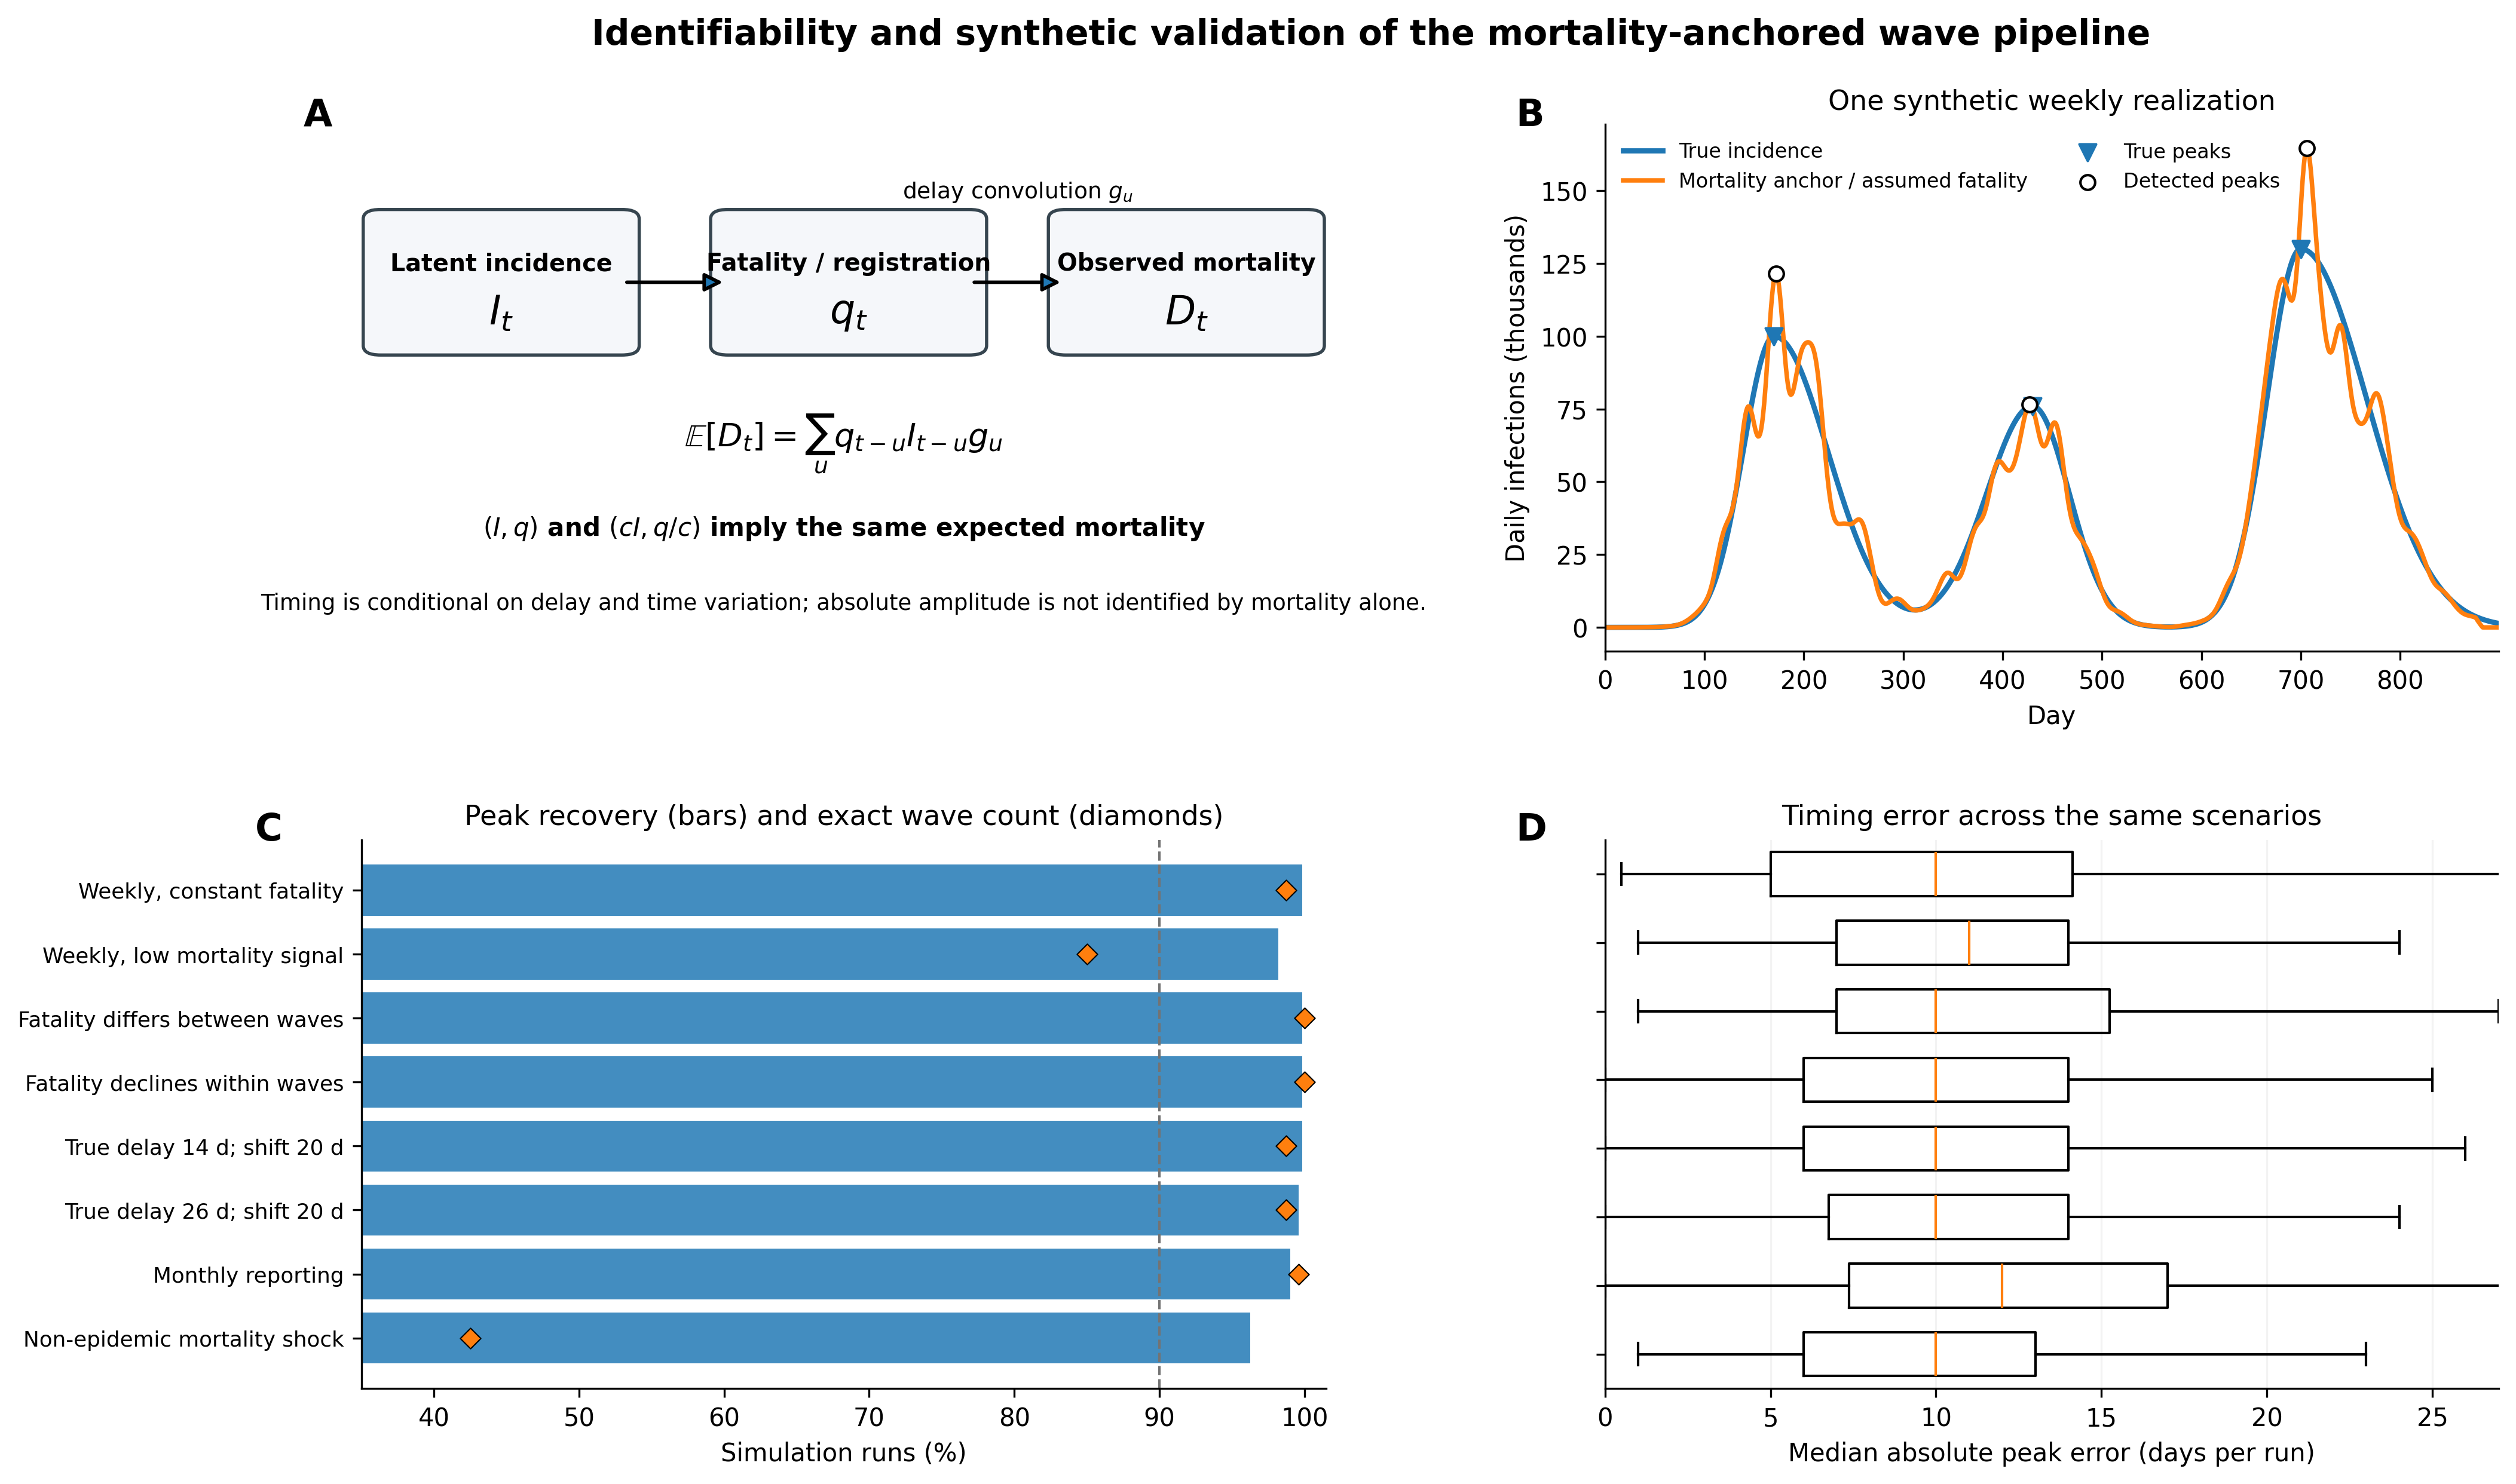

V26_Figure2_COVID_national_wave_geometry.png


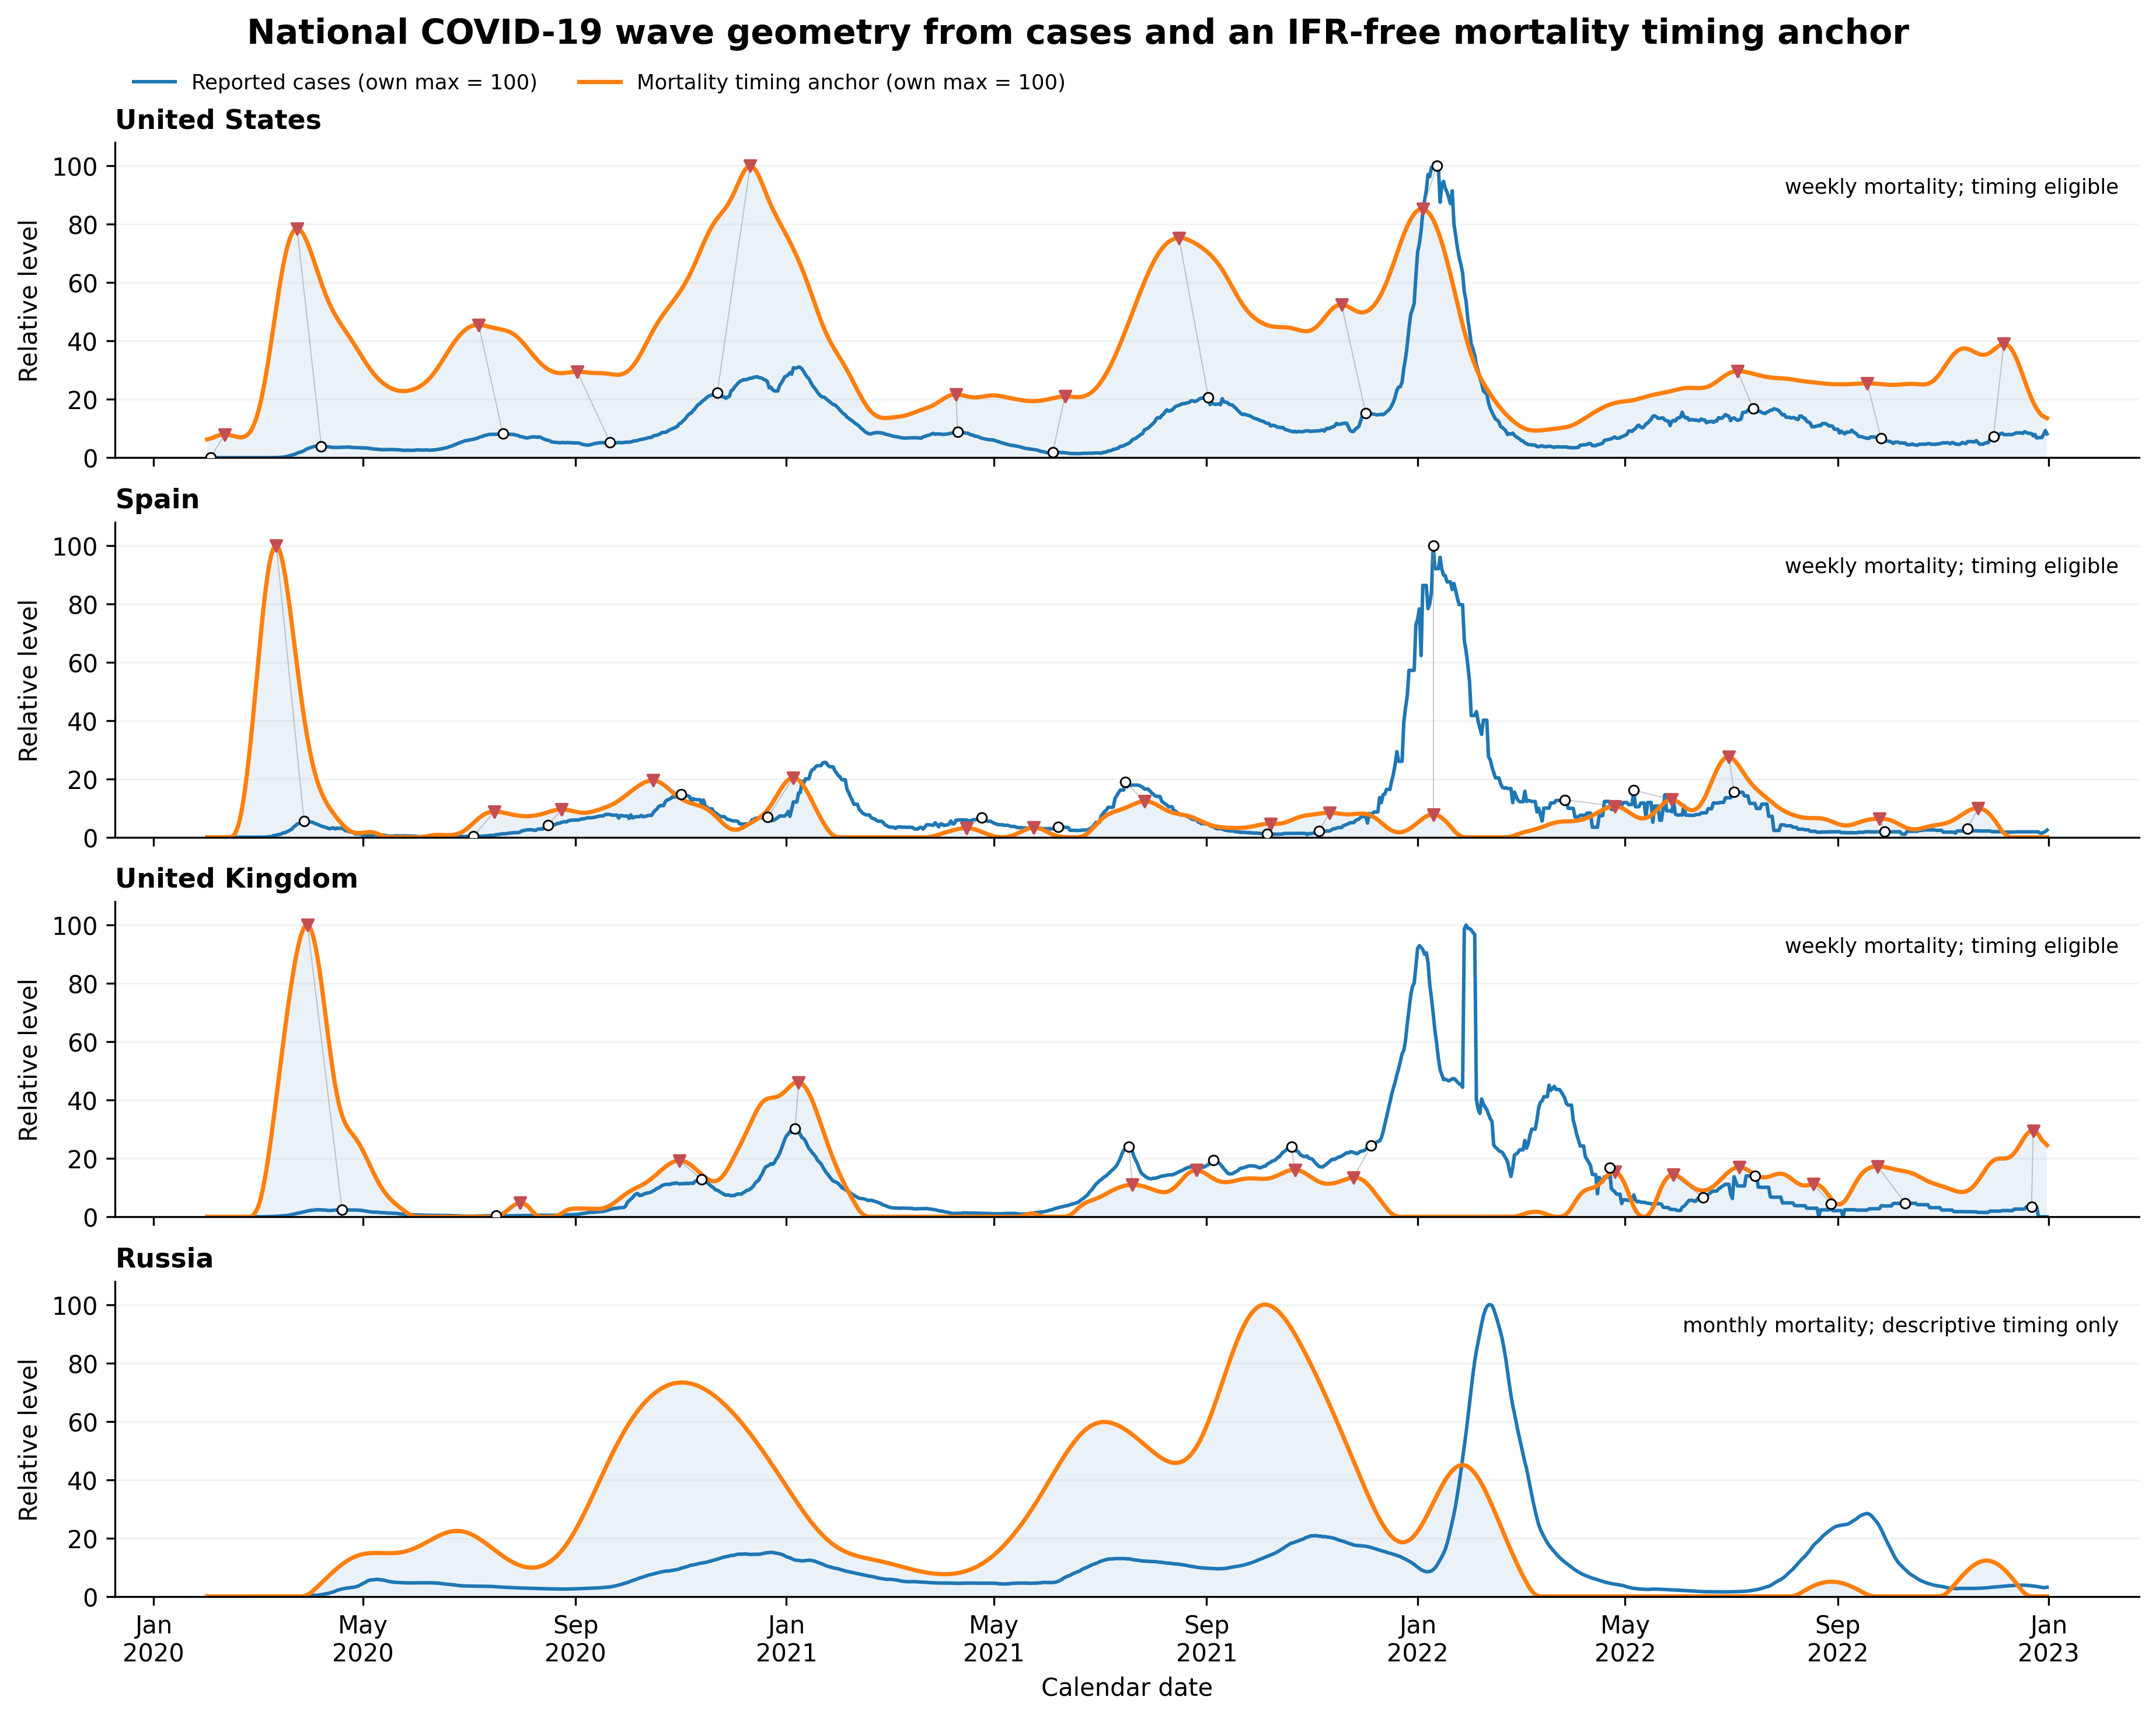

V26_Figure3_global_amplitude_maps.png


In [6]:
for name in [
    'V26_Figure1_identifiability_simulation.png',
    'V26_Figure2_COVID_national_wave_geometry.png',
    'V26_Figure3_global_amplitude_maps.png',
]:
    print(name)
    display(Image(filename=str(FIGURES / name), width=900))

## 6. Regenerate the V2.10 historical figure

The U.S. spring Army signal is retained only as a chronology/morbidity sentinel; no unsupported national spring infection count is manufactured.


V2.10 historical figure and table regenerated.



,Territory,Wave,Window,Deaths_source_linked,Infections_equivalent_primary,Population_pct_primary,EFR_primary
0,United States,W1,Sep-Dec 1918,362070,36207000.0,44.226015,0.010
1,Spain,W1,May-Jul 1918,17859,714360.0,3.484610,0.025
2,Spain,W2,Aug-Dec 1918,218081,8723240.0,42.551496,0.025
3,Spain,W3,Jan-Apr 1919,11380,455200.0,2.220441,0.025
4,England & Wales,W1,23 Jun-14 Sep 1918,10466,1046600.0,3.135131,0.010
5,England & Wales,W2,15 Sep 1918-25 Jan 1919,96375,9637500.0,28.869507,0.010
6,England & Wales,W3,26 Jan-10 May 1919,37013,3701300.0,11.087388,0.010
7,British India,W1,Jun-Aug 1918,371810,7436200.0,3.117953,0.050
8,British India,W2,Sep-Dec 1918,6440817,128816340.0,54.011900,0.050
9,British India,W3,Jan 1919,488318,9766360.0,4.094975,0.050


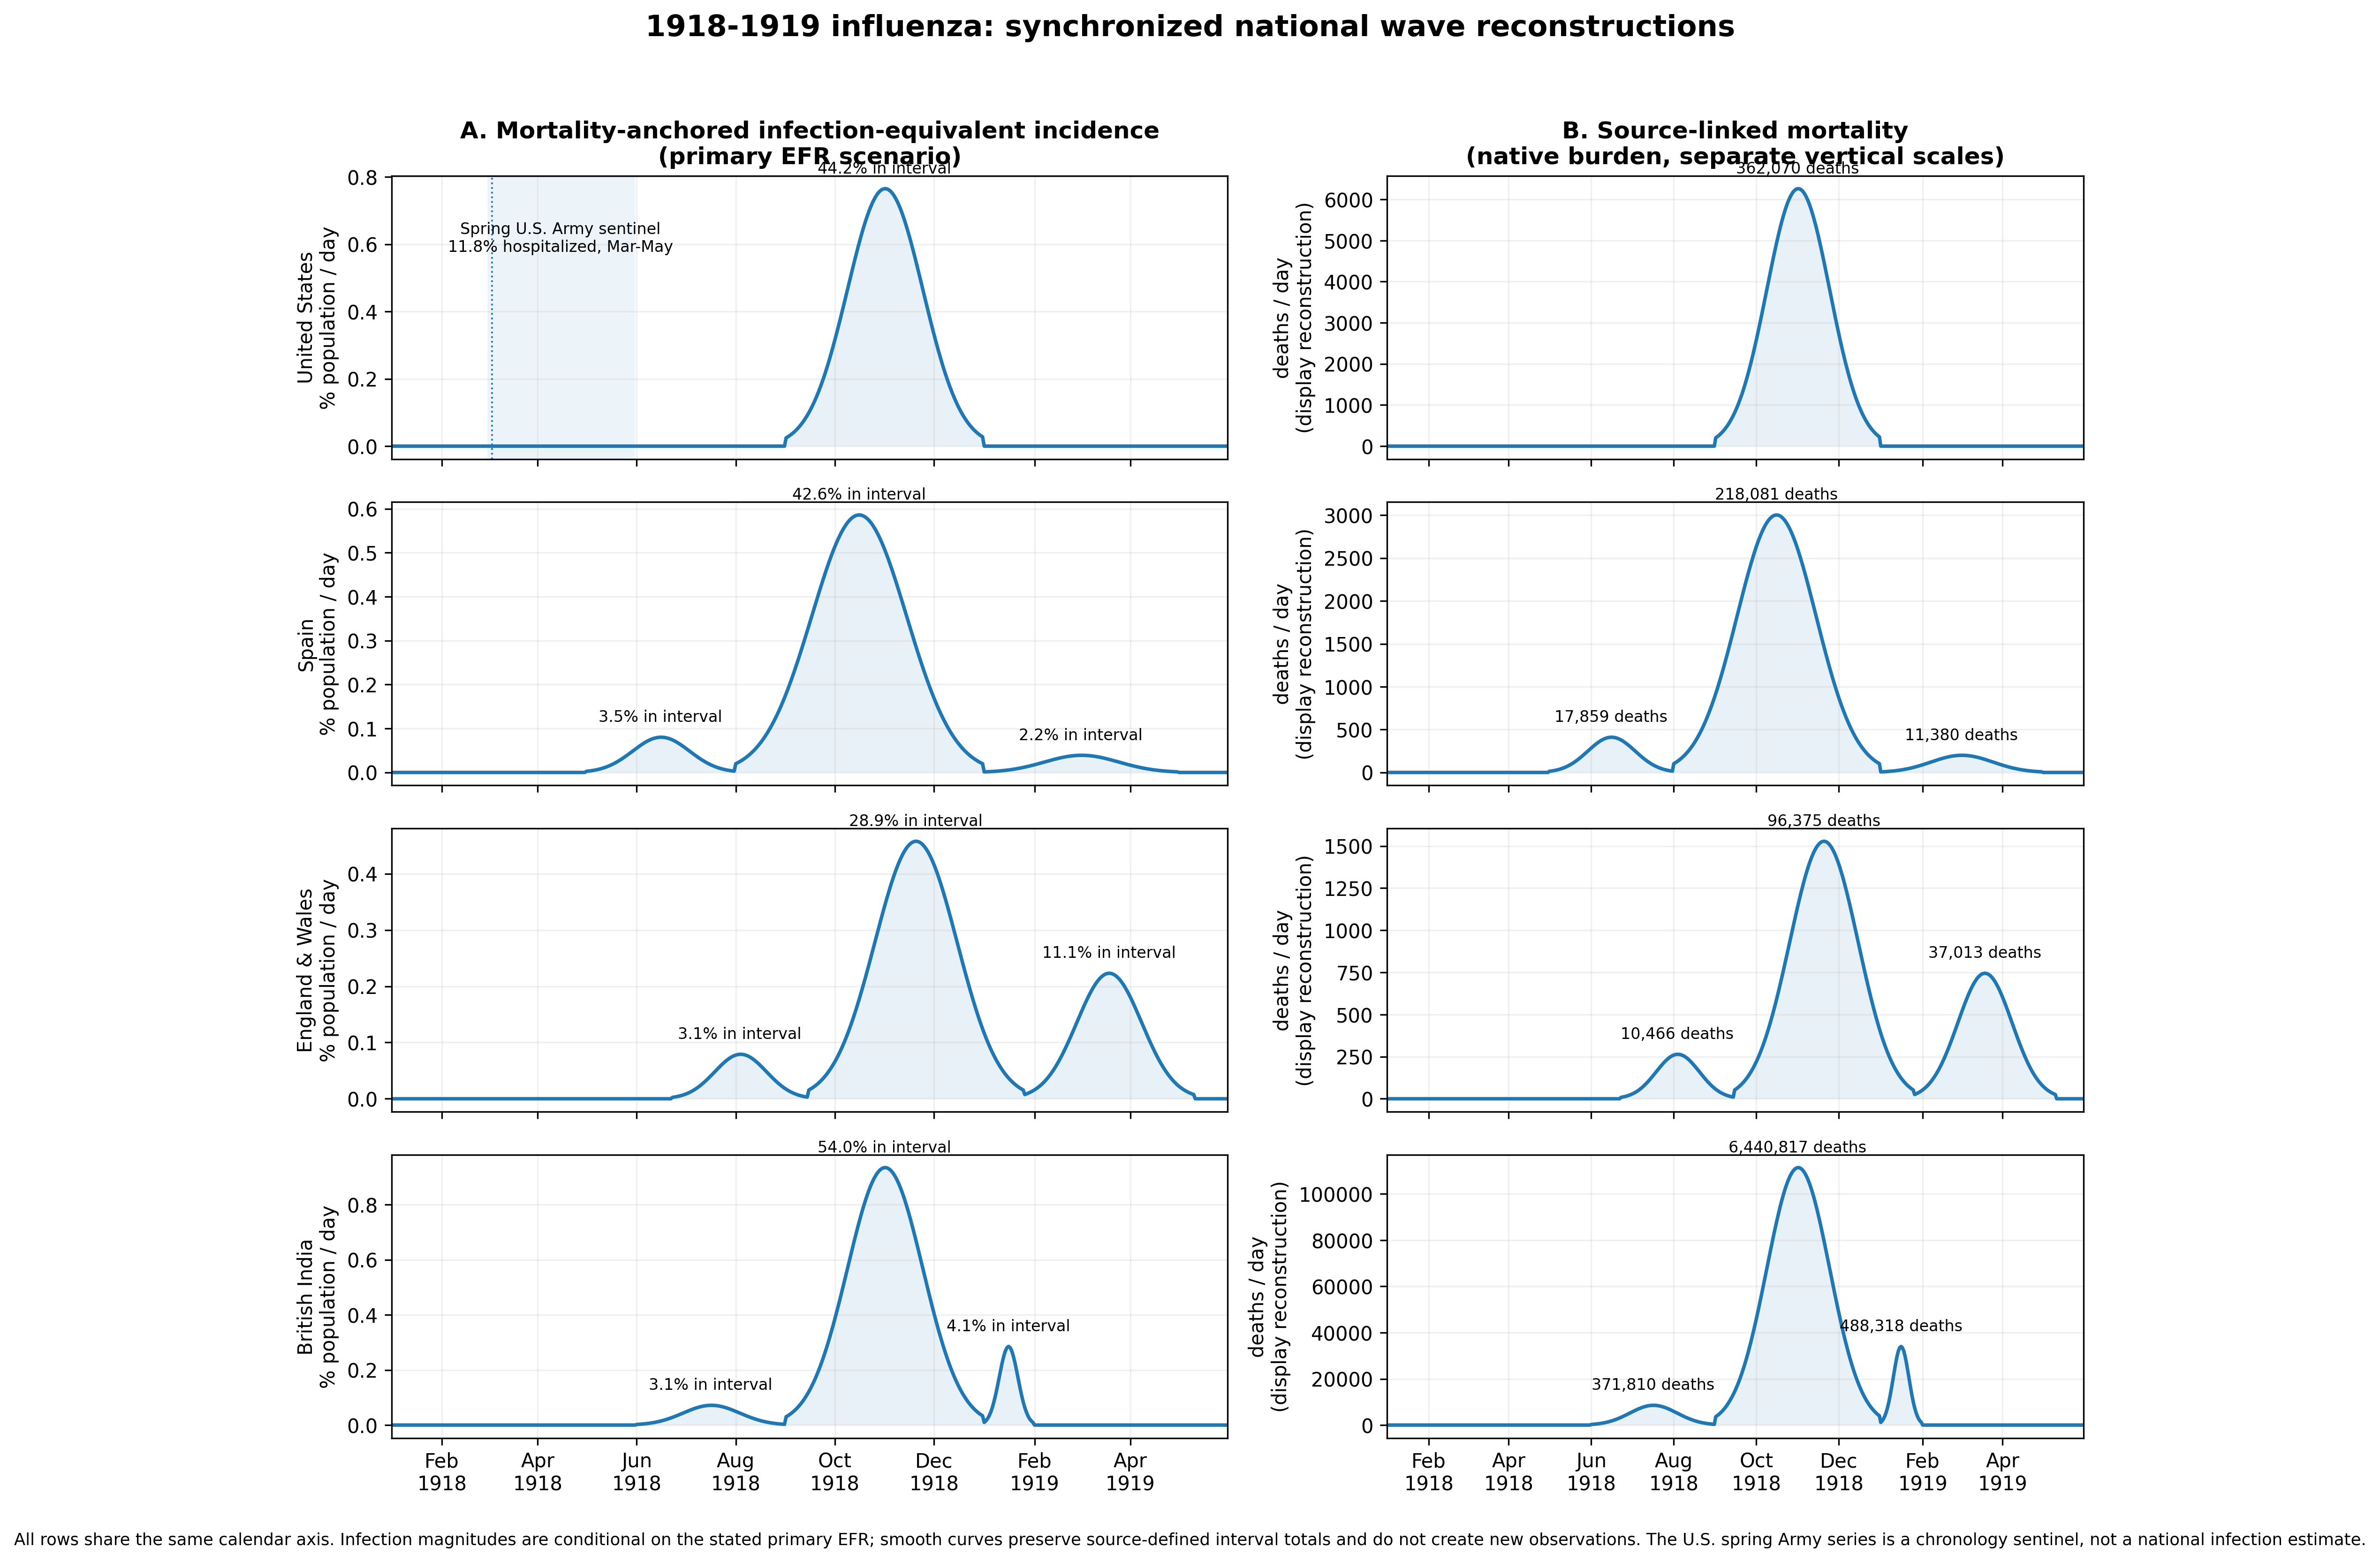

In [7]:
proc = subprocess.run([sys.executable, str(REPRO / 'generate_v210_historical_figure.py')], cwd=ROOT, env=env, text=True, capture_output=True, check=True)
print(proc.stdout)
v210_hist = pd.read_csv(TABLES / 'V210_1918_wave_burdens.csv')
display(v210_hist)
assert len(v210_hist) == 10
display(Image(filename=str(FIGURES / 'V210_Figure4_1918_infections_mortality.png'), width=1100))


## 7. Write the results-to-return archive


In [8]:
proc = subprocess.run(
    [sys.executable, str(REPRO / 'build_results_archive.py')],
    cwd=ROOT, env=env, text=True, capture_output=True, check=True
)
print(proc.stdout)
manifest = json.loads((TABLES / 'V26_results_archive_manifest.json').read_text())
assert manifest['sha256'] == sha256(ROOT / manifest['archive'])
print(json.dumps(manifest, indent=2))
shutil.rmtree(REPRO / 'Epidemics_V24_Results', ignore_errors=True)

{
  "archive": "EPIDEMICS_V26_RESULTS_TO_RETURN.zip",
  "sha256": "573cdbbb013a962e6c1640fb2bfc69e9e2587ba15d0ec81c335b165205416709",
  "bytes": 558170
}

{
  "archive": "EPIDEMICS_V26_RESULTS_TO_RETURN.zip",
  "sha256": "573cdbbb013a962e6c1640fb2bfc69e9e2587ba15d0ec81c335b165205416709",
  "bytes": 558170
}


## V2.12 final visual reconstruction and portability boundary

The final manuscript reports two separate trajectory families. COVID-19 Figures 2 and 3 display conditional infection-equivalent incidence and the unshifted H3-regularized mortality curve, respectively, together with wave-specific burden ledgers. Historical Figures 5 and 6 make the same distinction for 1918, retaining the U.S. Army spring morbidity and mortality sentinels separately from the civilian death-registration-area numerator. Overlapping smooth display components preserve each archived wave or interval integral and do not alter detection, matching, or inference.

Portability applies to the documented workflow and decision rules. Delay and IFR/EFR parameters remain setting-specific and are not transported unchanged across countries, pathogens, or historical eras.

Release target: `v2.12.0-epidemics` at `santigarciacc/epidemiological-archaeology`. Current archival record: `10.5281/zenodo.19561613`.